In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [9]:
os.chdir("/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance,
    display_colored_sentences
)

/u/sebono/conversational_dominance/notebooks/information_exchange_labelling


In [10]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



In [11]:
import pandas as pd
import re
import numpy as np

multisimo_df_with_annotations = pd.read_csv("/u/sebono/conversational_dominance/data/processed/multisimo/transcript_dominance.csv")
multisimo_df_with_annotations

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,<MOD>: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,<MOD> Ok hello we are going to play a quiz. <...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"<MOD>: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"<MOD>: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"<MOD>: <MOD>: Ok. So welcome, thank you very m...",P016,P017
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,2.0,2.4,2.8,<MOD>: So good evening <SPK2>: Good evening. <...,P018,P019
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,3.0,3.6,3.6,<MOD>: Ok <SPK2>: Yeah so <MOD>: So I would li...,P020,P021
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,2.0,2.8,2.6,<MOD>: Ok. So I would like us to play a quiz. ...,P022,P023
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,1.0,3.6,1.4,"<SPK1>: <MOD>: Right. So, I would like us to p...",P024,P025
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,2.4,1.4,"<SPK1>: yeah <MOD>: Well hello, thanks very mu...",P028,P029


In [12]:
from glob import glob
import os, re, pickle
import numpy as np
import re
import pandas as pd
from tqdm import tqdm

BASE = "/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results"


def _pair_distinguishable(spk_dict, alpha=0.05, adjust_p="fdr_bh"):
    """
    Returns True if <SPK1> and <SPK2> are statistically distinguishable
    by any test in compute_significance (after correction if requested).
    """
    # Only consider main speakers that are present
    spks = [s for s in spk_dict.keys() if s.startswith("<SPK")]
    if not ("<SPK1>" in spks and "<SPK2>" in spks):
        return False

    # Your function (must be in scope)
    results_list, results_dict = compute_significance(
        original_ppls_p_spk=spk_dict,
        spk_tokens=["<SPK1>", "<SPK2>"],
        alternative_mw="two-sided",
        equal_var_ttest=False,
        adjust_p=adjust_p
    )

    # Prefer adjusted p if present; otherwise raw p
    best_p = 1.0
    for row in results_list:
        if (row.get("spk_i"), row.get("spk_j")) in [("<SPK1>", "<SPK2>"), ("<SPK2>", "<SPK1>")]:
            p = row.get("p_value_adj", row.get("p_value"))
            if p is not None and not np.isnan(p):
                best_p = min(best_p, p)
    return best_p < alpha

def compute_dominance(dataset, model, ppls, base=BASE, agg=np.nanmean):
    out = {}
    rows = []

    for idx, name in enumerate(list(multisimo_df_with_annotations["file_name"])):
        el = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"]
        dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"][list(el.keys())[0]]

        pattern = r'<(?:SPK[0-9]|MOD)>'
        dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
        matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
        token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
        encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
        assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
        assert len(matches) == len(dialog_lines)

        all_data = pd.DataFrame({})
        for p_name in ['p1','p2','p3']:
            file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model}/dominance_scores_{name}.pkl'
            with open(file_name_sample, 'rb') as f:
                all_data[f"{p_name}"] = pickle.load(f)[name]

        filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

        filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

        filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

        #assert len(filtered_tokens_p3) == len(token_list)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
        assert filtered_encodings_p1 == filtered_encodings_p2
        assert filtered_encodings_p1 == filtered_encodings_p3
        filtered_encodings = filtered_encodings_p1

        all_data = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
        all_data.bfill(inplace=True)

        baselined_ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
        baselined_ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
        baselined_ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

        out[name] = {}
        out[name]['p1'] = dict(zip(baselined_ppls_p1_spk.keys(), [np.mean(baselined_ppls_p1_spk[key]) for key in baselined_ppls_p1_spk.keys()]))
        out[name]['p2'] = dict(zip(baselined_ppls_p2_spk.keys(), [np.mean(baselined_ppls_p2_spk[key]) for key in baselined_ppls_p2_spk.keys()]))
        out[name]['p3'] = dict(zip(baselined_ppls_p3_spk.keys(), [np.mean(baselined_ppls_p3_spk[key]) for key in baselined_ppls_p3_spk.keys()]))

        # Collect tidy rows
        for ppl_key in ('p1','p2','p3'):
            for spk, val in out[name][ppl_key].items():
                rows.append((name, ppl_key, spk, float(val) if val is not None else np.nan))

    df = pd.DataFrame(rows, columns=["file_name", "ppl", "speaker", "mean_dominance"])

    # Pivot ppl into columns
    pivot = (
        df.pivot_table(index=["file_name", "speaker"],
                       columns="ppl", values="mean_dominance", aggfunc="mean")
        .reindex(columns=["p1","p2","p3"])
        .reset_index()
    )

    # Add human dominance scores
    dom_long = (
        multisimo_df_with_annotations[["file_name", "speaker_1_dom_score", "speaker_2_dom_score"]]
        .melt(id_vars="file_name", var_name="which", value_name="dom")
        .assign(speaker=lambda d: d["which"].map({
            "speaker_1_dom_score": "<SPK1>",
            "speaker_2_dom_score": "<SPK2>",
        }))
        .drop(columns="which")
    )

    result = (
        pivot.merge(dom_long, on=["file_name","speaker"], how="left")
             .loc[:, ["file_name","speaker","dom","p1","p2","p3"]]
             .sort_values(["file_name","speaker"])
             .reset_index(drop=True)
    )

    return result, out

In [13]:
DATASET = "multisimo"      # e.g. "multisimo"
MODEL = model_id           # e.g. "gpt2-large"
PPLS = ["p1", "p2", "p3"]  # which folders to scan

data, out_data = compute_dominance(DATASET, MODEL, PPLS)

Token indices sequence length is longer than the specified maximum sequence length for this model (4955 > 1024). Running this sequence through the model will result in indexing errors


In [17]:
out_data

{'S02': {'p1': {'<MOD>': 3.6739254981233014,
   '<SPK1>': 3.8596730731858626,
   '<SPK2>': 3.6922118924423217},
  'p2': {'<MOD>': 2.715826810258712,
   '<SPK1>': 2.094027783774154,
   '<SPK2>': 2.086008924995189},
  'p3': {'<MOD>': 2.902191417052014,
   '<SPK1>': 3.204166486789363,
   '<SPK2>': 2.9502199805731593}},
 'S03': {'p1': {'<MOD>': 3.531708490780364,
   '<SPK2>': 3.9732215543050247,
   '<SPK1>': 3.6148435418259037},
  'p2': {'<MOD>': 2.628981876081009,
   '<SPK2>': 1.9856274172451824,
   '<SPK1>': 1.8771603469536684},
  'p3': {'<MOD>': 3.0613160546732034,
   '<SPK2>': 2.993319763391504,
   '<SPK1>': 3.0141139623160673}},
 'S04': {'p1': {'<MOD>': 3.2148973383056547,
   '<SPK2>': 3.833444860819727,
   '<SPK1>': 3.5654226296414158},
  'p2': {'<MOD>': 2.4917520277390177,
   '<SPK2>': 2.1001309847831724,
   '<SPK1>': 1.9043291015423611},
  'p3': {'<MOD>': 3.2526048327965564,
   '<SPK2>': 3.2331725118034766,
   '<SPK1>': 3.7887790004953703}},
 'S05': {'p1': {'<MOD>': 3.3143658747559

In [15]:
multisimo_df_with_annotations

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,<MOD>: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,<MOD> Ok hello we are going to play a quiz. <...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"<MOD>: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"<MOD>: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"<MOD>: <MOD>: Ok. So welcome, thank you very m...",P016,P017
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,2.0,2.4,2.8,<MOD>: So good evening <SPK2>: Good evening. <...,P018,P019
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,3.0,3.6,3.6,<MOD>: Ok <SPK2>: Yeah so <MOD>: So I would li...,P020,P021
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,2.0,2.8,2.6,<MOD>: Ok. So I would like us to play a quiz. ...,P022,P023
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,1.0,3.6,1.4,"<SPK1>: <MOD>: Right. So, I would like us to p...",P024,P025
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,2.4,1.4,"<SPK1>: yeah <MOD>: Well hello, thanks very mu...",P028,P029


In [19]:
import pandas as pd

rows = []

for file_name, phases in out_data.items():
    row = {"file_name": file_name}
    for p, roles in phases.items():
        for role, value in roles.items():
            row[f"{role}_{p}"] = value
    rows.append(row)

ppl_df = pd.DataFrame(rows)
ppl_df

,file_name,<MOD>_p1,<SPK1>_p1,<SPK2>_p1,<MOD>_p2,<SPK1>_p2,<SPK2>_p2,<MOD>_p3,<SPK1>_p3,<SPK2>_p3
0,S02,3.673925,3.859673,3.692212,2.715827,2.094028,2.086009,2.902191,3.204166,2.950220
1,S03,3.531708,3.614844,3.973222,2.628982,1.877160,1.985627,3.061316,3.014114,2.993320
2,S04,3.214897,3.565423,3.833445,2.491752,1.904329,2.100131,3.252605,3.788779,3.233173
3,S05,3.314366,3.833553,3.412965,2.600927,2.005451,2.161347,2.985529,2.988865,3.126620
4,S07,3.666423,3.694508,3.336642,2.611721,1.812375,1.622964,2.928134,3.219100,3.290029
5,S08,3.809710,3.595748,3.686150,2.850759,1.761660,1.737376,2.929864,3.569559,3.357007
6,S09,3.366666,3.457629,3.321281,2.375487,1.845813,1.785329,2.919158,2.989340,3.039983
7,S10,3.299268,3.699754,3.808591,2.593326,1.995611,1.919434,3.573841,3.582191,3.303069
8,S11,3.382167,3.855456,3.361408,2.572804,2.043912,1.915491,2.834975,3.512773,3.464343
9,S13,3.482520,3.480789,3.957331,2.556800,1.685946,2.065628,2.952077,3.404395,3.544259


In [21]:
final_df = multisimo_df_with_annotations.merge(
    ppl_df,
    left_on="file_name",
    right_on="file_name",
    how="inner"
)
final_df

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,...,speaker_2,<MOD>_p1,<SPK1>_p1,<SPK2>_p1,<MOD>_p2,<SPK1>_p2,<SPK2>_p2,<MOD>_p3,<SPK1>_p3,<SPK2>_p3
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,...,P007,3.673925,3.859673,3.692212,2.715827,2.094028,2.086009,2.902191,3.204166,2.950220
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,...,P009,3.531708,3.614844,3.973222,2.628982,1.877160,1.985627,3.061316,3.014114,2.993320
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,...,P011,3.214897,3.565423,3.833445,2.491752,1.904329,2.100131,3.252605,3.788779,3.233173
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,...,P013,3.314366,3.833553,3.412965,2.600927,2.005451,2.161347,2.985529,2.988865,3.126620
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,...,P017,3.666423,3.694508,3.336642,2.611721,1.812375,1.622964,2.928134,3.219100,3.290029
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,...,P019,3.809710,3.595748,3.686150,2.850759,1.761660,1.737376,2.929864,3.569559,3.357007
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,...,P021,3.366666,3.457629,3.321281,2.375487,1.845813,1.785329,2.919158,2.989340,3.039983
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,...,P023,3.299268,3.699754,3.808591,2.593326,1.995611,1.919434,3.573841,3.582191,3.303069
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,...,P025,3.382167,3.855456,3.361408,2.572804,2.043912,1.915491,2.834975,3.512773,3.464343
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,...,P029,3.482520,3.480789,3.957331,2.556800,1.685946,2.065628,2.952077,3.404395,3.544259


In [23]:
cols = ["speaker_1_dom_score", "speaker_2_dom_score", 
        "speaker_1_1", "speaker_1_2", "speaker_1_3", "speaker_1_4", 
        "speaker_1_5", "speaker_2_1", "speaker_2_2", "speaker_2_3", "speaker_2_4", "speaker_2_5", 
        "<SPK1>_p1", "<SPK2>_p1", "<SPK1>_p2", "<SPK2>_p2", "<SPK1>_p3", "<SPK2>_p3"]
comparison_ppl_dom_data = data.merge(final_df, on="file_name")[cols]
comparison_ppl_dom_data

,speaker_1_dom_score,speaker_2_dom_score,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,<SPK1>_p1,<SPK2>_p1,<SPK1>_p2,<SPK2>_p2,<SPK1>_p3,<SPK2>_p3
0,2.0,3.4,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,3.859673,3.692212,2.094028,2.086009,3.204166,2.950220
1,2.0,3.4,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,3.859673,3.692212,2.094028,2.086009,3.204166,2.950220
2,2.0,3.4,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,3.859673,3.692212,2.094028,2.086009,3.204166,2.950220
3,2.0,3.4,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,3.614844,3.973222,1.877160,1.985627,3.014114,2.993320
4,2.0,3.4,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,3.614844,3.973222,1.877160,1.985627,3.014114,2.993320
5,2.0,3.4,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,3.614844,3.973222,1.877160,1.985627,3.014114,2.993320
6,2.0,1.6,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,3.565423,3.833445,1.904329,2.100131,3.788779,3.233173
7,2.0,1.6,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,3.565423,3.833445,1.904329,2.100131,3.788779,3.233173
8,2.0,1.6,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,3.565423,3.833445,1.904329,2.100131,3.788779,3.233173
9,3.8,2.0,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.833553,3.412965,2.005451,2.161347,2.988865,3.126620


In [132]:
col_1 = ["speaker_1_1","speaker_1_2","speaker_1_3","speaker_1_4","speaker_1_5",
         "speaker_2_1","speaker_2_2","speaker_2_3","speaker_2_4","speaker_2_5"]
col_2 = ["<SPK1>_p1","<SPK1>_p2","<SPK1>_p3","<SPK2>_p1","<SPK2>_p2","<SPK2>_p3"]
#col_1 = ["p1", "p2", "p3"]
#col_2 = ["dom"]

In [133]:
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,comparison_ppl_dom_data)

In [134]:
fig_corr

In [135]:
fig_p

In [144]:
from scipy.stats import spearmanr
import pandas as pd
import itertools

results = []

speakers = ["<SPK1>", "<SPK2>"]
phases = ["p2", "p3"]

for spk in speakers:
    # all unordered phase pairs: (p1,p2), (p1,p3), (p2,p3)
    for p_a, p_b in itertools.combinations(phases, 2):
        col_a = f"{spk}_{p_a}"
        col_b = f"{spk}_{p_b}"

        x = comparison_ppl_dom_data[col_a]
        y = comparison_ppl_dom_data[col_b]
        mask = x.notna() & y.notna()

        if mask.sum() < 2:
            r, pval = float("nan"), float("nan")
        else:
            r, pval = spearmanr(x[mask], y[mask])

        results.append({
            "speaker": spk,
            "phase_a": p_a,
            "phase_b": p_b,
            "feature_a": col_a,
            "feature_b": col_b,
            "spearman_r": r,
            "p_value": pval,
            "abs_r": abs(r) if pd.notna(r) else float("nan"),
            "n": mask.sum()
        })

phase_corr_table = (
    pd.DataFrame(results)
    .sort_values("abs_r", ascending=False)
)

phase_corr_table

,speaker,phase_a,phase_b,feature_a,feature_b,spearman_r,p_value,abs_r,n
0,<SPK1>,p2,p3,<SPK1>_p2,<SPK1>_p3,0.339525,0.012015,0.339525,54
1,<SPK2>,p2,p3,<SPK2>_p2,<SPK2>_p3,-0.085655,0.538000,0.085655,54


In [147]:
from scipy.stats import spearmanr
import pandas as pd

results = []

pairs = [
    ("<SPK1>", "speaker_1_1"),
    ("<SPK1>", "speaker_1_2"),
    ("<SPK1>", "speaker_1_3"),
    ("<SPK1>", "speaker_1_4"),
    ("<SPK1>", "speaker_1_5"),
    ("<SPK2>", "speaker_2_1"),
    ("<SPK2>", "speaker_2_2"),
    ("<SPK2>", "speaker_2_3"),
    ("<SPK2>", "speaker_2_4"),
    ("<SPK2>", "speaker_2_5"),
]

phases = ["p2", "p3"]

for spk, dom_col in pairs:
    for p in phases:
        ppl_col = f"{spk}_{p}"

        # Drop NaNs pairwise
        x = comparison_ppl_dom_data[ppl_col]
        y = comparison_ppl_dom_data[dom_col]
        mask = x.notna() & y.notna()

        if mask.sum() < 2:
            r, pval = float("nan"), float("nan")
        else:
            r, pval = spearmanr(x[mask], y[mask])

        results.append({
            "speaker": spk,
            "phase": p,
            "ppl_feature": ppl_col,
            "dom_feature": dom_col,
            "spearman_r": r,
            "p_value": pval,
            "abs_r": abs(r) if pd.notna(r) else float("nan")
        })

corr_table = pd.DataFrame(results).sort_values("abs_r", ascending=False)
corr_table

,speaker,phase,ppl_feature,dom_feature,spearman_r,p_value,abs_r
17,<SPK2>,p3,<SPK2>_p3,speaker_2_4,-0.596782,0.000002,0.596782
3,<SPK1>,p3,<SPK1>_p3,speaker_1_2,-0.581679,0.000004,0.581679
13,<SPK2>,p3,<SPK2>_p3,speaker_2_2,-0.527814,0.000041,0.527814
18,<SPK2>,p2,<SPK2>_p2,speaker_2_5,-0.445579,0.000734,0.445579
14,<SPK2>,p2,<SPK2>_p2,speaker_2_3,-0.444062,0.000769,0.444062
10,<SPK2>,p2,<SPK2>_p2,speaker_2_1,-0.426901,0.001285,0.426901
11,<SPK2>,p3,<SPK2>_p3,speaker_2_1,-0.423667,0.001412,0.423667
15,<SPK2>,p3,<SPK2>_p3,speaker_2_3,-0.416169,0.001748,0.416169
1,<SPK1>,p3,<SPK1>_p3,speaker_1_1,-0.406560,0.002284,0.406560
5,<SPK1>,p3,<SPK1>_p3,speaker_1_3,-0.377426,0.004901,0.377426


In [148]:
corr_table[corr_table["speaker"]=="<SPK2>"]

,speaker,phase,ppl_feature,dom_feature,spearman_r,p_value,abs_r
17,<SPK2>,p3,<SPK2>_p3,speaker_2_4,-0.596782,0.000002,0.596782
13,<SPK2>,p3,<SPK2>_p3,speaker_2_2,-0.527814,0.000041,0.527814
18,<SPK2>,p2,<SPK2>_p2,speaker_2_5,-0.445579,0.000734,0.445579
14,<SPK2>,p2,<SPK2>_p2,speaker_2_3,-0.444062,0.000769,0.444062
10,<SPK2>,p2,<SPK2>_p2,speaker_2_1,-0.426901,0.001285,0.426901
11,<SPK2>,p3,<SPK2>_p3,speaker_2_1,-0.423667,0.001412,0.423667
15,<SPK2>,p3,<SPK2>_p3,speaker_2_3,-0.416169,0.001748,0.416169
19,<SPK2>,p3,<SPK2>_p3,speaker_2_5,-0.374641,0.005254,0.374641
12,<SPK2>,p2,<SPK2>_p2,speaker_2_2,-0.254291,0.063517,0.254291
16,<SPK2>,p2,<SPK2>_p2,speaker_2_4,-0.237840,0.083307,0.237840


In [ ]:
comparison_ppl_dom_data

In [128]:
comparison_ppl_dom_data["<SPK2>_p_mean"] = comparison_ppl_dom_data[["<SPK2>_p1", "<SPK2>_p2", "<SPK2>_p3"]].mean(axis=1)

from scipy.stats import spearmanr
spearmanr(comparison_ppl_dom_data["<SPK2>_p_mean"], comparison_ppl_dom_data["speaker_2_dom_score"])

SignificanceResult(statistic=-0.40109022116030096, pvalue=0.0026493447252849546)

In [129]:
comparison_ppl_dom_data["<SPK1>_p_mean"] = comparison_ppl_dom_data[["<SPK1>_p1", "<SPK1>_p2", "<SPK1>_p3"]].mean(axis=1)

from scipy.stats import spearmanr
spearmanr(comparison_ppl_dom_data["<SPK1>_p_mean"], comparison_ppl_dom_data["speaker_1_dom_score"])

SignificanceResult(statistic=-0.24127066607386302, pvalue=0.07882388104690477)

### Analysis

In [71]:
name="S18"
dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==file_name]["file_content"][17]

In [72]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model_id}/dominance_scores_{name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[name]

In [73]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [74]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


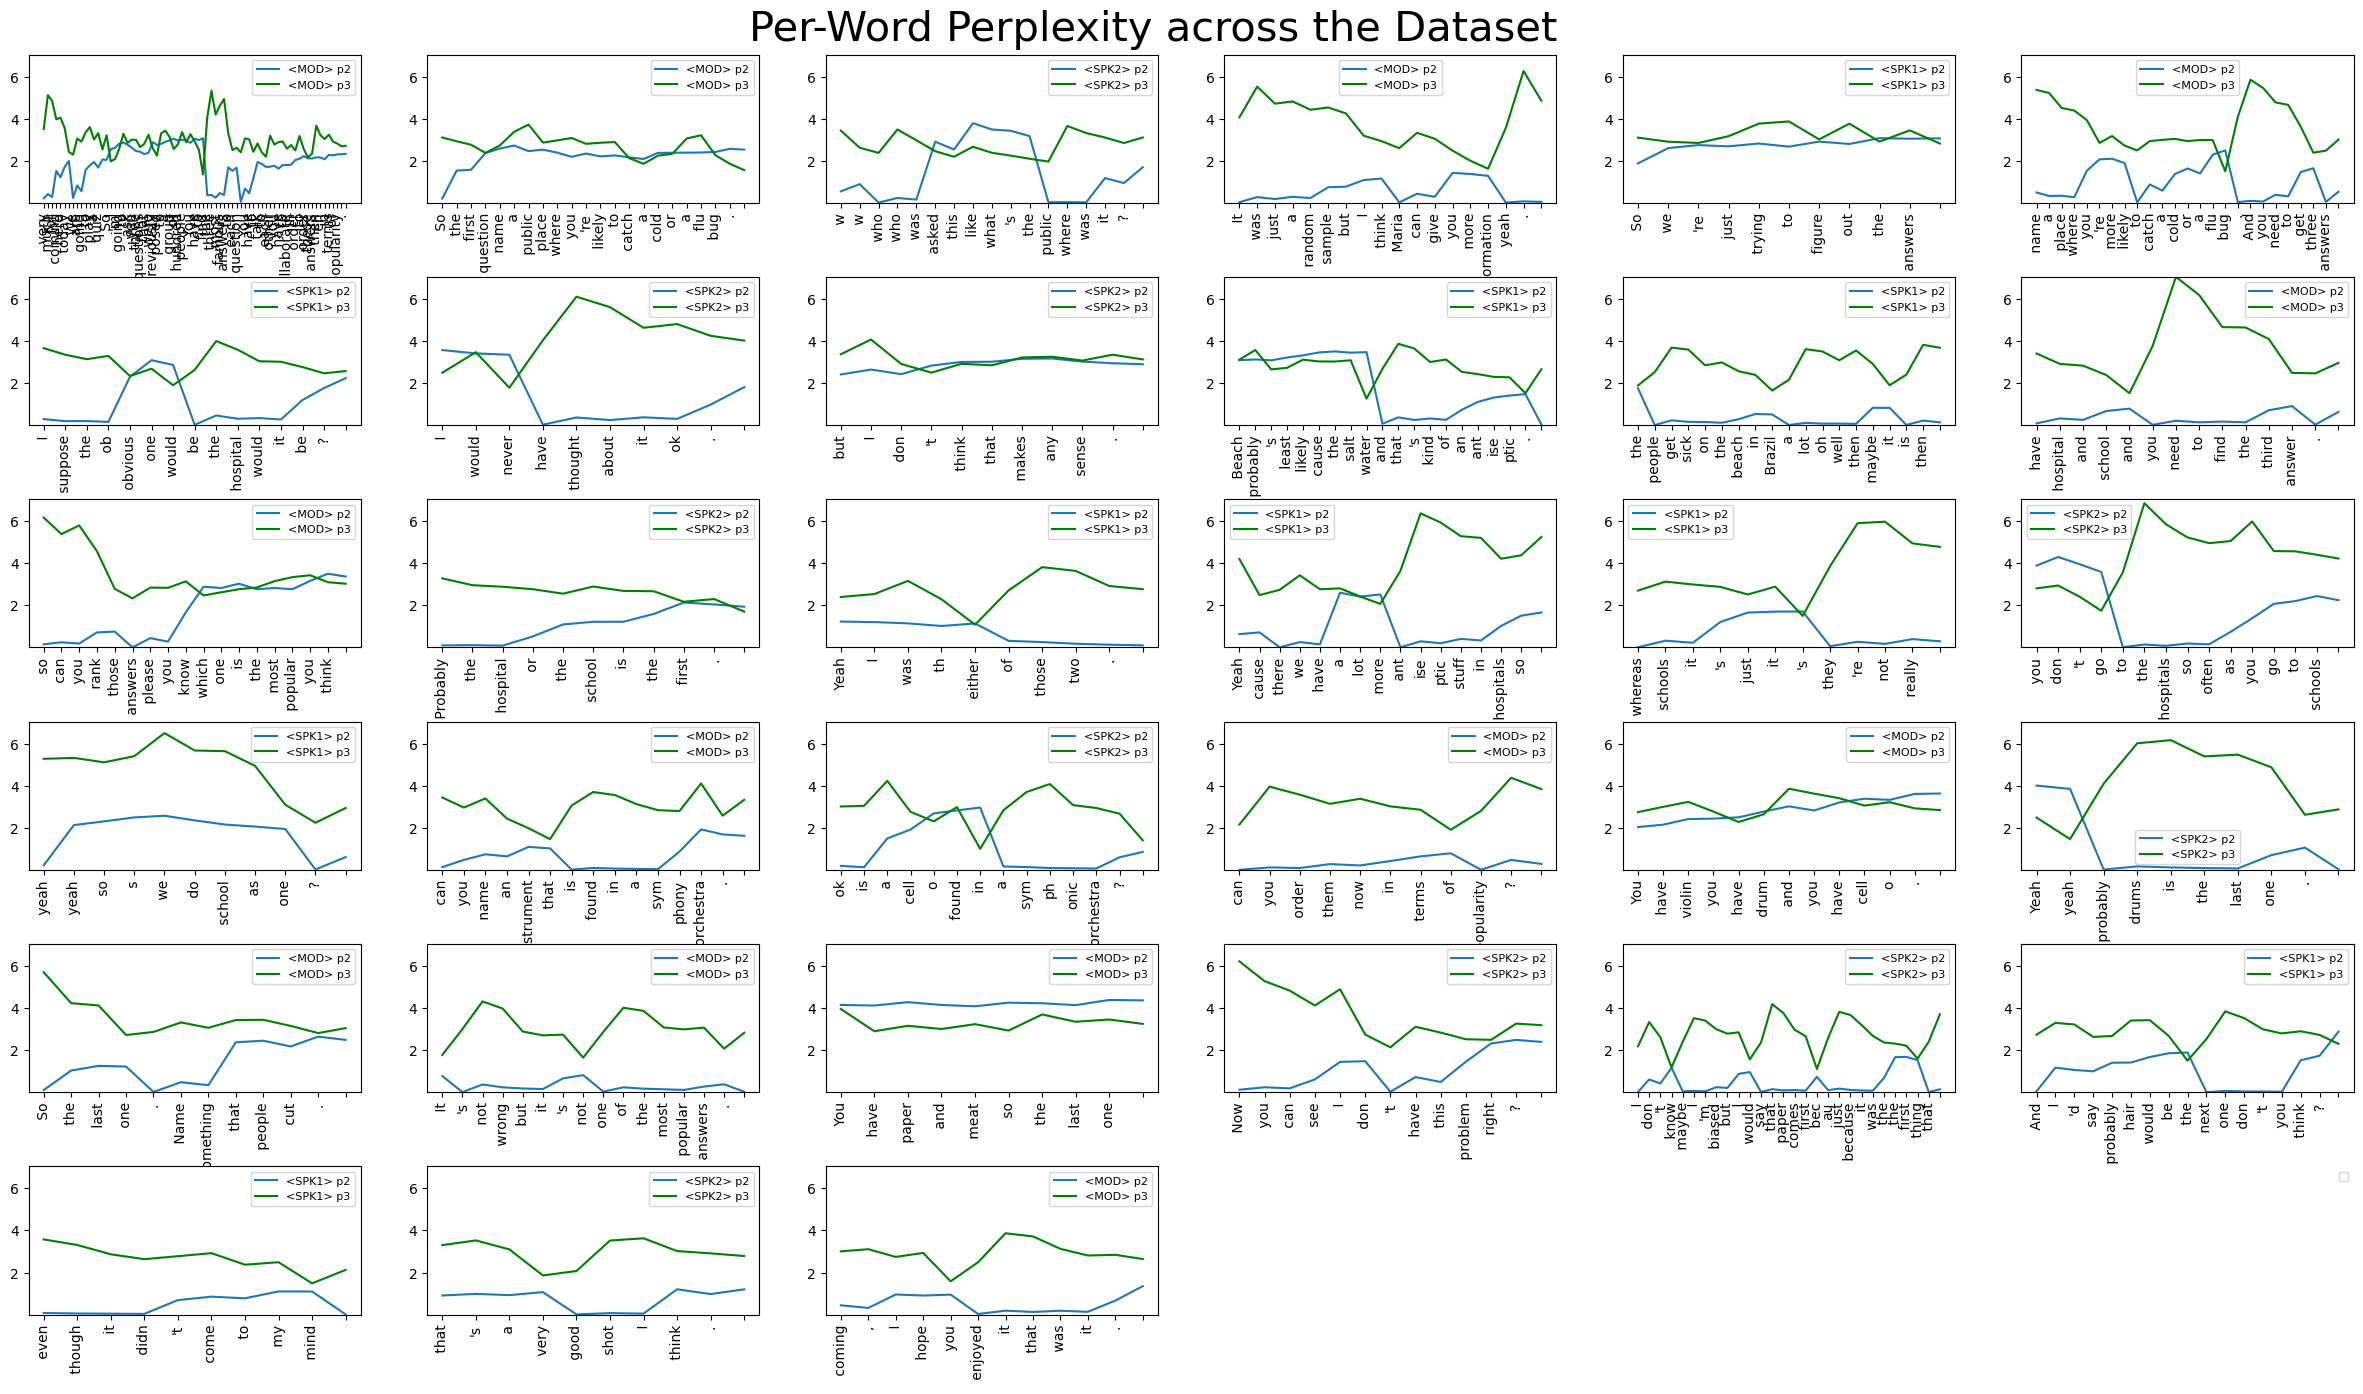

In [75]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p2[:end], filtered_ppl_p3[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [76]:
ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [77]:
np.mean(ppls_p2_spk["<SPK1>"])

1.137576908315697

In [78]:
np.mean(ppls_p2_spk["<SPK2>"])

1.2120051248896895

In [79]:
np.mean(ppls_p3_spk['<SPK1>']), np.mean(ppls_p3_spk['<SPK2>'])

(3.213128106813904, 3.2532147966700493)

In [80]:
np.mean(ppls_p1_spk['<SPK1>']) > np.mean(ppls_p1_spk['<SPK2>']), np.mean(ppls_p2_spk['<SPK1>']) > np.mean(ppls_p2_spk['<SPK2>']), np.mean(ppls_p3_spk['<SPK1>']) < np.mean(ppls_p3_spk['<SPK2>'])

(False, False, True)

In [81]:
rows, nested = compute_significance(ppls_p2_spk, ['<SPK1>', '<SPK2>'], adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,141,139,0.097199,0.477785,0.477785
1,Mann-Whitney U,<SPK1>,<SPK2>,141,139,9803.000000,0.996467,0.996467
2,T-test,<SPK1>,<SPK2>,141,139,-0.533469,0.594143,0.594143


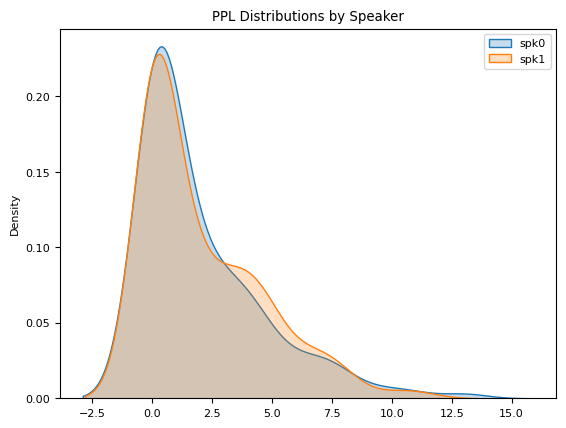

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

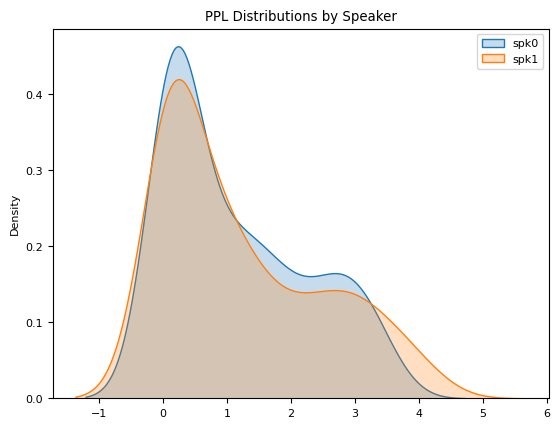

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

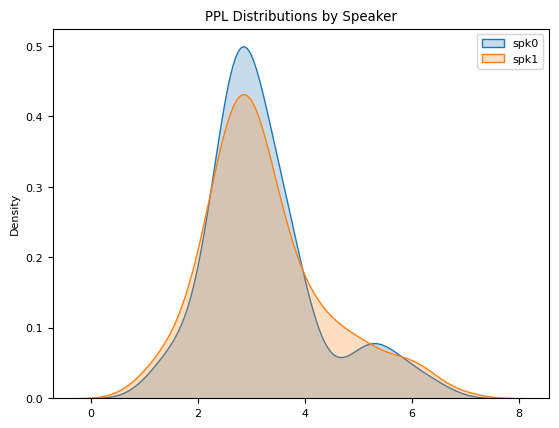

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [85]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [86]:
fig_corr

In [87]:
fig_p

### Per-turn Analysis

In [88]:
per_turn_ppl = pd.DataFrame({"tokens": filtered_tokens_p1})

In [89]:
from itertools import count

# Start from offset
start_index = 0
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

per_turn_ppl["ppl"] = per_turn_ppl["tokens"].apply(assign_indices)

In [90]:
per_turn_ppl["ppl"].iloc[-1][-1], len(filtered_ppl_p3)

(538, 539)

In [91]:
np.mean(filtered_ppl_p3[0:8])

3.7199787497520447

In [92]:
per_turn_ppl["speaker"] = filtered_matches_p1

In [93]:
per_turn_ppl["p1"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p2"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p3"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

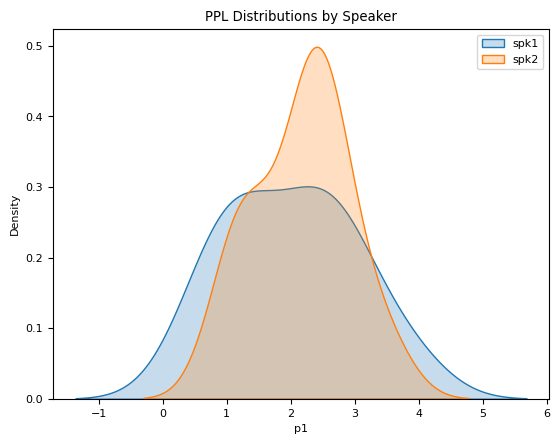

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

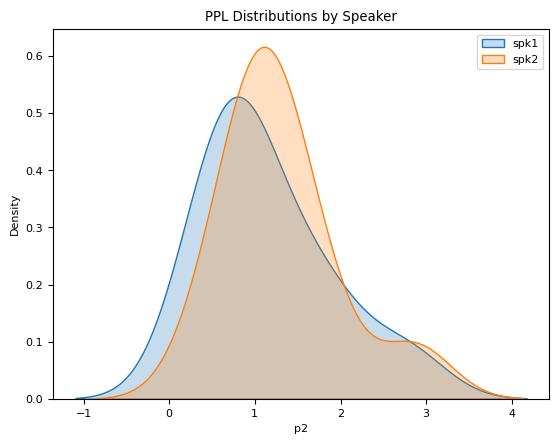

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

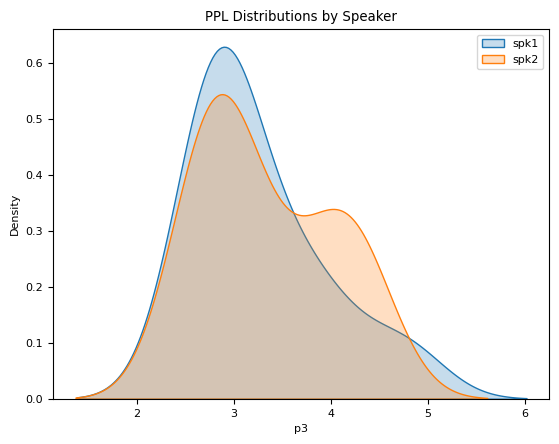

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [97]:
ppls_p1_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p1']})
ppls_p2_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p2']})
ppls_p3_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p3']})

In [98]:
rows, nested = compute_significance(ppls_p1_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
1,KS,<MOD>,<SPK2>,13,10,0.307692,0.549662,0.919571
2,KS,<SPK1>,<SPK2>,10,10,0.300000,0.786930,0.919571
0,KS,<MOD>,<SPK1>,13,10,0.207692,0.919571,0.919571
4,Mann-Whitney U,<MOD>,<SPK2>,13,10,60.000000,0.780185,0.876787
5,Mann-Whitney U,<SPK1>,<SPK2>,10,10,46.000000,0.791337,0.876787
3,Mann-Whitney U,<MOD>,<SPK1>,13,10,62.000000,0.876787,0.876787
8,T-test,<SPK1>,<SPK2>,10,10,-0.425848,0.675777,0.962405
6,T-test,<MOD>,<SPK1>,13,10,0.372829,0.713029,0.962405
7,T-test,<MOD>,<SPK2>,13,10,0.047773,0.962405,0.962405


In [99]:
rows, nested = compute_significance(ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
1,KS,<MOD>,<SPK2>,13,10,0.361538,0.361187,0.919571
2,KS,<SPK1>,<SPK2>,10,10,0.300000,0.786930,0.919571
0,KS,<MOD>,<SPK1>,13,10,0.207692,0.919571,0.919571
5,Mann-Whitney U,<SPK1>,<SPK2>,10,10,39.000000,0.427355,0.925883
4,Mann-Whitney U,<MOD>,<SPK2>,13,10,57.000000,0.641838,0.925883


In [100]:
rows, nested = compute_significance(ppls_p3_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<MOD>,<SPK1>,13,10,0.446154,0.149675,0.449025
1,KS,<MOD>,<SPK2>,13,10,0.346154,0.398021,0.597031
2,KS,<SPK1>,<SPK2>,10,10,0.200000,0.994458,0.994458
3,Mann-Whitney U,<MOD>,<SPK1>,13,10,79.000000,0.402461,0.909722
4,Mann-Whitney U,<MOD>,<SPK2>,13,10,69.000000,0.828161,0.909722
5,Mann-Whitney U,<SPK1>,<SPK2>,10,10,48.000000,0.909722,0.909722
7,T-test,<MOD>,<SPK2>,13,10,-0.405489,0.691933,0.974636
8,T-test,<SPK1>,<SPK2>,10,10,-0.287115,0.777303,0.974636
6,T-test,<MOD>,<SPK1>,13,10,-0.032436,0.974636,0.974636


In [101]:
per_turn_ppl["dialog"] = per_turn_ppl["tokens"].map(lambda x: " ".join([tokenizer.decode(token, skip_special_tokens=True) for token in x]))

In [102]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,per_turn_ppl)

In [103]:
fig_corr

In [104]:
fig_p

In [105]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(per_turn_ppl['p3'], per_turn_ppl[col_1], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": col_1,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
2,p3,1.000000,0.000000
1,p2,0.112968,0.531356
0,p1,-0.039439,0.827502
